# ADMM for Sparse Recovery from $y=Ax_0$

We solve the LASSO problem
$$
\min_x \frac12\|Ax-y\|_2^2 + \lambda\|x\|_1
$$
with ADMM splitting. For $\lambda_{\max}=\|A^\top y\|_\infty$, the minimizer is $x=0$.
We use $\lambda=\lambda_{\max}/10$ to recover a sparse ground-truth $x_0$.


## Sparse target generation


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython
ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")
m, n = 75, 180
A = rng.normal(size=(m, n)) / np.sqrt(m)
x0 = np.zeros(n)
supp = rng.choice(n, size=11, replace=False)
x0[supp] = rng.normal(0, 1.2, size=len(supp))
y = A @ x0
lam_max = np.max(np.abs(A.T @ y))
lam = lam_max / 10
print(f"lambda_max={lam_max:.3e}, lambda={lam:.3e}")


lambda_max=2.103e+00, lambda=2.103e-01


## ADMM iterations and iterate trajectory


In [2]:
rho = 1.0
ATA = A.T @ A
M = np.linalg.inv(ATA + rho*np.eye(n))
x = np.zeros(n); z = np.zeros(n); u = np.zeros(n)
hist = [x.copy()]
for _ in range(160):
    x = M @ (A.T @ y + rho*(z - u))
    z = np.sign(x + u) * np.maximum(np.abs(x + u) - lam/rho, 0)
    u = u + x - z
    hist.append(x.copy())
hist = np.array(hist)
err = np.linalg.norm(hist - x0[None, :], axis=1) / (np.linalg.norm(x0) + 1e-12)


## Signal reconstruction and evolution


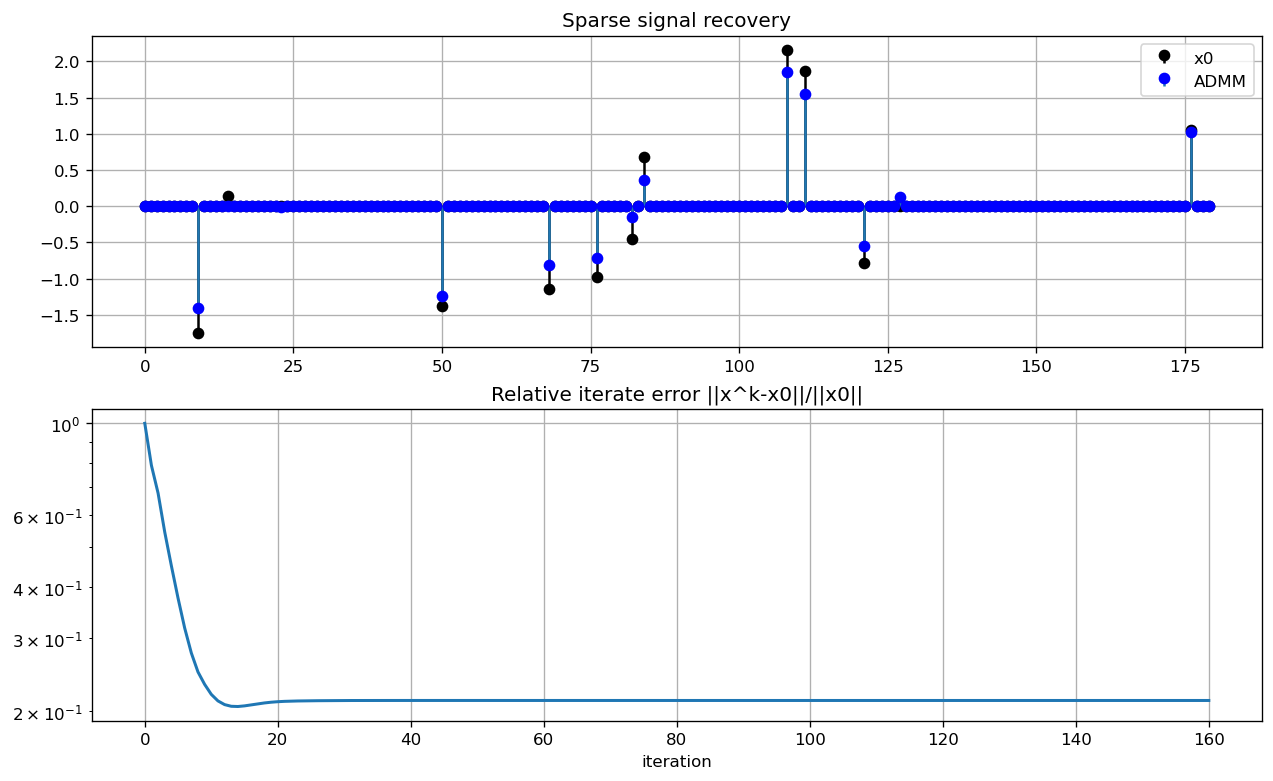

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(10.5, 6.4), constrained_layout=True)
axes[0].stem(x0, linefmt="k-", markerfmt="ko", basefmt=" ", label="x0")
axes[0].stem(hist[-1], linefmt="tab:blue", markerfmt="bo", basefmt=" ", label="ADMM")
axes[0].set_title("Sparse signal recovery")
axes[0].legend()
axes[1].semilogy(err, lw=1.8)
axes[1].set_title("Relative iterate error ||x^k-x0||/||x0||")
axes[1].set_xlabel("iteration")
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()
